# MWE: reconstructing an image from AMI-like data

An image fit in virgil is an ordinary call to `fit` whose model contains an `Image`. The pixels' log-brightnesses get flat priors from `virgil.imaging.image_priors`, and a regulariser supplies the prior information that the data cannot: here maximum entropy, which prefers images close to a flat default. The unresolved star stays an analytic `PointSource` at the origin, which also fixes the image's position, since the data are blind to shifts.

The data are simulated with `virgil.coverage.ami_grid_record`, which mimics AMIGO's representation of AMI: complex visibilities on a fine uv grid, of which only the mask's splodges carry information, compressed into orthonormal modes that keep 99% of the precision and are blind to the source's flux and position. The extended emission has only 3% of the star's flux. You should come away able to set up an image fit, compare it with the truth, and read its diagnostics.

In [1]:
import sys
from pathlib import Path

root = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists()
)
sys.path.insert(0, str(root / "src"))

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from virgil.coverage import ami_grid_record
from virgil.fitting import fit
from virgil.imaging import (
    MaxEntropy,
    beam,
    diagnose,
    field_of_view,
    image_priors,
    nyquist_pixel_scale,
)
from virgil.likelihood import whitened_residuals
from virgil.models import GaussianDisk, Image, PointSource, System
from virgil.oidata import OIData
from virgil.plotting import plot_model, plot_residual_map
from virgil.scenes import ring

template = OIData(ami_grid_record(wavelength_m=4.8e-6, rotation_deg=-6.9))
scale, flux = 20.0, 0.03
npix = round(
    field_of_view(template, largest_mas=1250.0) / scale
)  # ~8 beams across
truth_image = ring(
    npix,
    scale,
    240.0,
    36.0,
    inc_deg=50.0,
    pa_deg=30.0,
    asymmetry=0.5,
    asymmetry_pa_deg=90.0,
)
truth = System(
    star=PointSource(),
    env=Image.from_brightness(truth_image, scale, flux=flux),
)
data = template.with_model(truth, key=jax.random.PRNGKey(0))
print(f"{template.u.size} uv cells in the splodges, {data.vis.size} modes")
print(
    f"{npix}² pixels of {scale} mas (Nyquist: {nyquist_pixel_scale(data):.0f} mas), a {npix * scale:.0f} mas field"
)

412 uv cells in the splodges, 588 modes
62² pixels of 20.0 mas (Nyquist: 84 mas), a 1240 mas field


## The fit

The fit starts from a blurred Gaussian with the right flux, a stand-in for a parametric fit. Maximum entropy has no least-squares form, so `fit` uses L-BFGS. The weight of 100 is close to where χ² per data point reaches one in the L-curve of the next MWE (the discrepancy principle).

In [2]:
start = System(
    star=PointSource(),
    env=Image.from_model(GaussianDisk(180.0), npix, scale, flux=flux),
)
regularisers = [MaxEntropy(100.0, path="env")]
result = fit(start, image_priors(start), data, regularisers)
info = result.info
print(
    f"{info['method']}: converged = {info['converged']} after {info['steps']} steps, chi2 per point {info['chi2_red']:.3f}"
)

lbfgs: converged = True after 534 steps, chi2 per point 0.967


## Truth, reconstruction and residual

The ring is about three beams across, so its structure is resolved by the data. The shaded ellipse in the lower left of the reconstruction is the beam from `virgil.imaging.beam`, the FWHM of a Gaussian matched to the core of the data's dirty beam: roughly the size and shape of a resolution element. The right panel is the signed difference, reconstruction minus truth, on a symmetric scale; it has no uncertainty attached, so it is not a z-score. Red is flux the reconstruction adds and blue is flux it misses. All images are North up and East left.

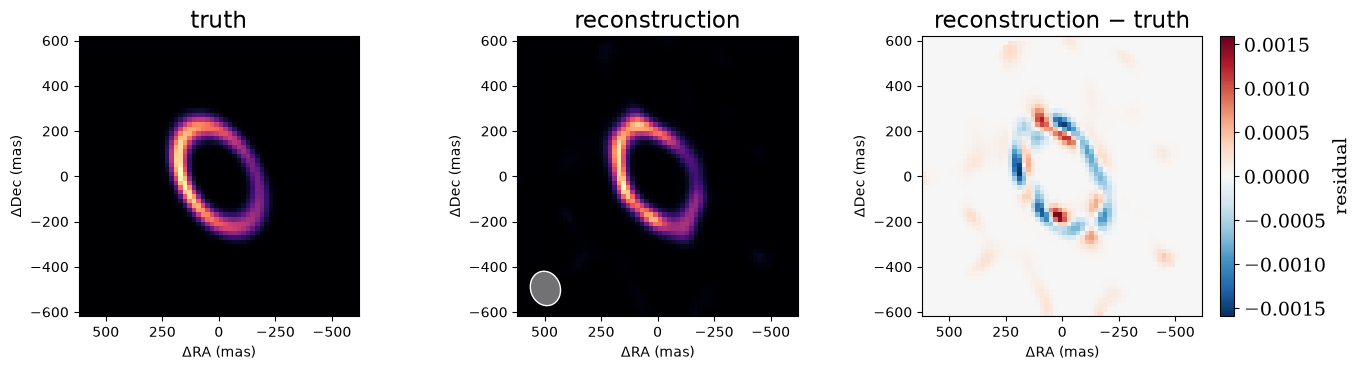

In [3]:
fov = npix * scale
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
plot_model(truth.env, fov_mas=fov, npix=npix, ax=axes[0], title="truth")
plot_model(
    result.model.env,
    fov_mas=fov,
    npix=npix,
    ax=axes[1],
    title="reconstruction",
    beam=beam(data),
)
difference = result.model.env.render(npix, fov) - truth.env.render(npix, fov)
plot_residual_map(
    difference, fov_mas=fov, ax=axes[2], title="reconstruction − truth"
)
plt.tight_layout()
plt.show()

## Residuals in the data

In the data, every mode has a known error, so here the residuals are z-scores, (model − data)/σ. They should look like unit-variance noise if the fit is good, and the histogram is compared with a standard normal curve.

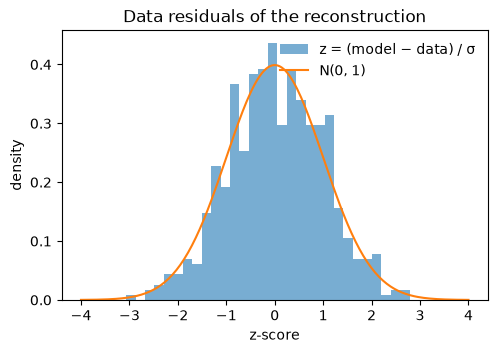

In [4]:
z = whitened_residuals(result.model, data)
x = jnp.linspace(-4, 4, 200)
fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.hist(z, bins=30, density=True, alpha=0.6, label="z = (model − data) / σ")
ax.plot(x, jnp.exp(-0.5 * x**2) / jnp.sqrt(2 * jnp.pi), label="N(0, 1)")
ax.set(
    xlabel="z-score",
    ylabel="density",
    title="Data residuals of the reconstruction",
)
ax.legend(frameon=False)
plt.show()

## Diagnostics

`diagnose` runs a set of checks on the fitted model: χ² per point, whether the pixels are fine enough, how much flux sits at the edge of the field, what fixes the position, whether the data constrain the orientation (the change in χ² when the image is rotated by 180°), and whether the model visibilities stay where projected phases are reliable. It warns only about actual problems.

In [5]:
print(diagnose(result.model, data, regularisers))

chi2_red         [0.967]
anchored         True
pixel_scale_mas  [20]
edge_flux        [0.00448]
centroid_mas     [[44.5, 12.8]]
flip_dchi2       5.43e+03
phase_regime     [0]

No warnings.


## Summary

Reconstructing an image takes a `System` with an analytic star and an `Image`, flat priors from `image_priors`, one regulariser and a call to `fit`. On AMI-like data with realistic, splodge-limited information and a faint ring (3% of the star's flux) about three beams across, maximum entropy recovers the ring, its hole and its brighter eastern side, fits the data to the noise and passes `diagnose`; the residual map shows the remaining differences, at the ring's narrow edges. How strong to make the regulariser is the subject of the next MWE.